# 04 - Explainability và Leakage Checklist cho báo cáo nộp thi
## Mục tiêu
Giải thích các yếu tố dẫn động doanh thu theo ngôn ngữ kinh doanh và tạo checklist kiểm soát leakage để đưa vào báo cáo kỹ thuật.

## Ràng buộc nộp thi được đáp ứng trong notebook này
1. Chỉ sử dụng dữ liệu nội bộ từ `daily_feature_table.parquet`.
2. Thiết lập seed để tái lập kết quả giải thích.
3. Giải thích mô hình bằng cả Feature Importance và SHAP.
4. Xuất file checklist leakage để đưa thẳng vào report.

## Đầu ra
- report/figures/feature_importance_top20.png
- report/figures/shap_summary.png
- report/feature_importance.csv
- report/leakage_checklist.md

## Giá trị cho doanh nghiệp
- Trả lời câu hỏi “Doanh thu tăng/giảm vì yếu tố nào” bằng bằng chứng định lượng.
- Giúp team Marketing, Supply Chain, Fulfillment ưu tiên đúng đòn bẩy vận hành.
- Giảm rủi ro triển khai sai do mô hình học nhầm tín hiệu bị leakage.

In [29]:
# 0. Setup, imports, and robust path resolution
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- REPRODUCIBILITY ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

# --- MODEL & EXPLAINABILITY TOOLS ---
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# --- ROBUST PATH RESOLUTION ---
def get_project_root() -> Path:
    """
    Ensures the project root is 'final'. 
    If running from 'notebooks' or 'model', move up one level.
    """
    curr = Path.cwd().resolve()
    # Fixed: Check for BOTH 'notebooks' and 'model' folders
    if curr.name in ["notebooks", "model"]:
        return curr.parent
    return curr

PROJECT_ROOT = get_project_root()

# Define output and report directories
FIG_DIR = PROJECT_ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Define data paths correctly relative to the new PROJECT_ROOT
INTERIM_DIR = PROJECT_ROOT / "dataset" / "interim"
SAFE_DATA_PATH = INTERIM_DIR / "daily_feature_table_model_safe.parquet"
DEFAULT_DATA_PATH = INTERIM_DIR / "daily_feature_table.parquet"

# Use the safe path if it exists, otherwise use the default
DATA_PATH = SAFE_DATA_PATH if SAFE_DATA_PATH.exists() else DEFAULT_DATA_PATH

# --- DATA LOADING ---
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Critical Error: Data file not found at {DATA_PATH}")

df = pd.read_parquet(DATA_PATH).sort_values("Date").reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

# --- FEATURE ENGINEERING ---

# 1. Time-based features
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["dayofweek"] = df["Date"].dt.dayofweek
df["dayofmonth"] = df["Date"].dt.day
df["weekend_flag"] = (df["dayofweek"] >= 5).astype(int)

# 2. Revenue Lag features (Previous values)
for lag in [1, 7, 14, 30, 365]:
    df[f"lag_{lag}"] = df["Revenue"].shift(lag)

# 3. Revenue Rolling Statistics (Moving averages/std dev)
df["rolling_mean_7"] = df["Revenue"].shift(1).rolling(7).mean()
df["rolling_mean_30"] = df["Revenue"].shift(1).rolling(30).mean()
df["rolling_std_7"] = df["Revenue"].shift(1).rolling(7).std()
df["rolling_std_30"] = df["Revenue"].shift(1).rolling(30).std()

# 4. COGS (Cost of Goods Sold) Lag & Rolling features
for lag in [1, 7, 14, 30, 365]:
    df[f"cogs_lag_{lag}"] = df["COGS"].shift(lag)

df["cogs_rolling_mean_7"] = df["COGS"].shift(1).rolling(7).mean()
df["cogs_rolling_mean_30"] = df["COGS"].shift(1).rolling(30).mean()
df["cogs_rolling_std_7"] = df["COGS"].shift(1).rolling(7).std()
df["cogs_rolling_std_30"] = df["COGS"].shift(1).rolling(30).std()

# Clean up: Remove rows with NaN values created by shifting/rolling
df = df.dropna().reset_index(drop=True)

# --- FINAL STATUS CHECK ---
print(f"Environment Status: SEED={SEED}, HAS_SHAP={HAS_SHAP}")
print(f"Project Root:       {PROJECT_ROOT}")
print(f"Loading from:       {DATA_PATH}")
print(f"Final Data Shape:   {df.shape}")
print(f"Columns generated:  {len(df.columns)}")

Environment Status: SEED=42, HAS_SHAP=True
Project Root:       D:\UNIVERSITY\PERSONAL_PROJECT\datathon\final
Loading from:       D:\UNIVERSITY\PERSONAL_PROJECT\datathon\final\dataset\interim\daily_feature_table_model_safe.parquet
Final Data Shape:   (3468, 158)
Columns generated:  158


In [30]:
if not HAS_LGB:
    raise ImportError("Please install lightgbm first: pip install lightgbm")

train = df[df["Date"] <= "2020-12-31"].copy()
valid = df[(df["Date"] >= "2021-01-01") & (df["Date"] <= "2021-12-31")].copy()

exclude_cols = [
    "Date", "Revenue", "COGS", "AOV", "aov",

    # same-day leakage features
    "total_orders", "cancelled_orders", "delivered_orders", "returned_orders",
    "total_payment_value", "avg_payment_value", "avg_installments",
    "total_quantity_sold", "total_discount_amount",
    "promo_line_count", "stacked_promo_count",
    "return_count", "total_refund_amount",
    "review_count", "avg_rating",
    "shipment_count", "avg_delivery_days", "avg_shipping_fee",
    "conversion_rate", "cancel_rate", "delivered_rate", "return_rate",
    "items_per_order", "discount_per_order", "payment_per_order",
    "pageviews_per_session"
]

feature_cols = [c for c in df.columns if c not in exclude_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

X_train = train[feature_cols]
X_valid = valid[feature_cols]

models = {}
valid_preds = {}

for target in ["Revenue", "COGS"]:
    print(f"\nTraining explainability model for {target}")

    y_train = train[target]
    y_valid = valid[target]

    m = lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        bagging_seed=SEED,
        feature_fraction_seed=SEED,
        data_random_seed=SEED,
        n_jobs=-1
    )

    m.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
    )

    models[target] = m
    valid_preds[target] = m.predict(X_valid)

print("Number of features:", len(feature_cols))
print("Sample features:", feature_cols[:20])


Training explainability model for Revenue
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32850
[LightGBM] [Info] Number of data points in the train set: 2738, number of used features: 152
[LightGBM] [Info] Start training from score 4566731.689372
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 538985	valid_0's l2: 5.91317e+11
Early stopping, best iteration is:
[171]	valid_0's l1: 537712	valid_0's l2: 5.9201e+11

Training explainability model for COGS
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32850
[LightGBM] [Info] Number of data points in the train set: 2738, number of used features: 152
[LightGBM] [Info] Start training from score 3947604.491874
Training until va

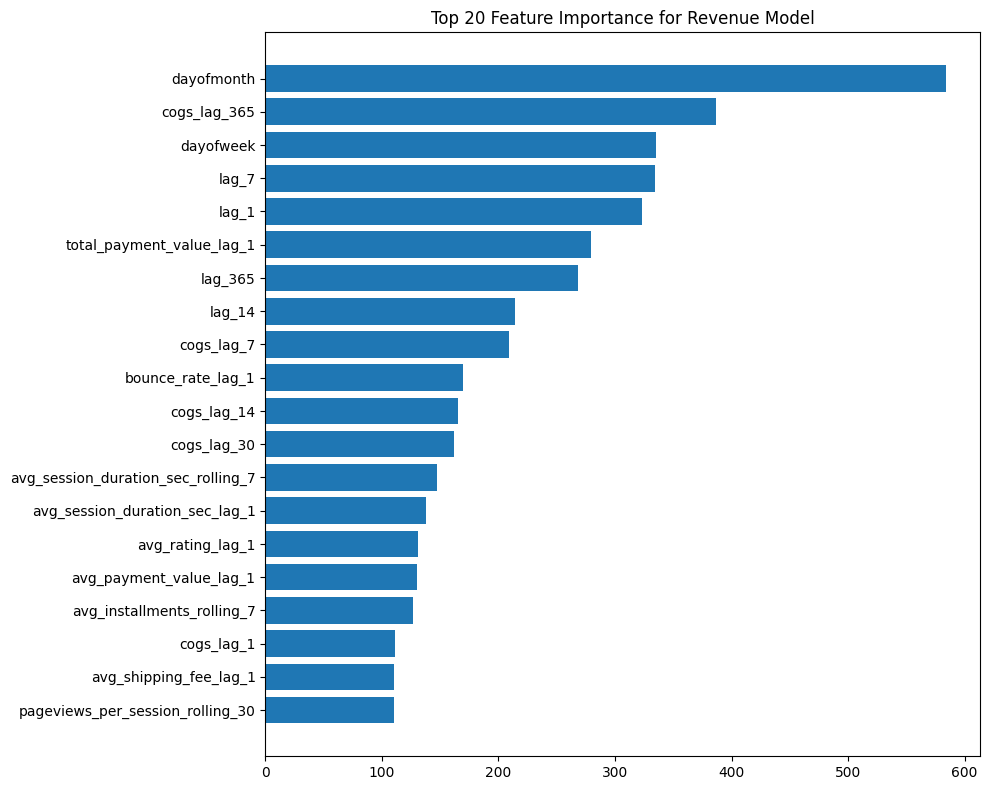

Top 10 important features for Revenue:


,feature,importance
135,dayofmonth,584
150,cogs_lag_365,387
134,dayofweek,335
138,lag_7,334
137,lag_1,323
38,total_payment_value_lag_1,279
141,lag_365,268
139,lag_14,214
147,cogs_lag_7,209
20,bounce_rate_lag_1,170


In [31]:
# Gain importance for Revenue model
model = models["Revenue"]

imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
topn = imp.head(20).iloc[::-1]
plt.barh(topn["feature"], topn["importance"])
plt.title("Top 20 Feature Importance for Revenue Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_top20_revenue.png", dpi=200)
plt.show()

imp.to_csv(PROJECT_ROOT / "report" / "feature_importance_revenue.csv", index=False)

print("Top 10 important features for Revenue:")
display(imp.head(10))


In [32]:
# Reproducibility note
print("Khong cai package truc tiep trong notebook de dam bao tinh tai lap.")
print("Neu thieu SHAP, cai ngoai notebook: pip install shap==0.48.0")

Khong cai package truc tiep trong notebook de dam bao tinh tai lap.
Neu thieu SHAP, cai ngoai notebook: pip install shap==0.48.0


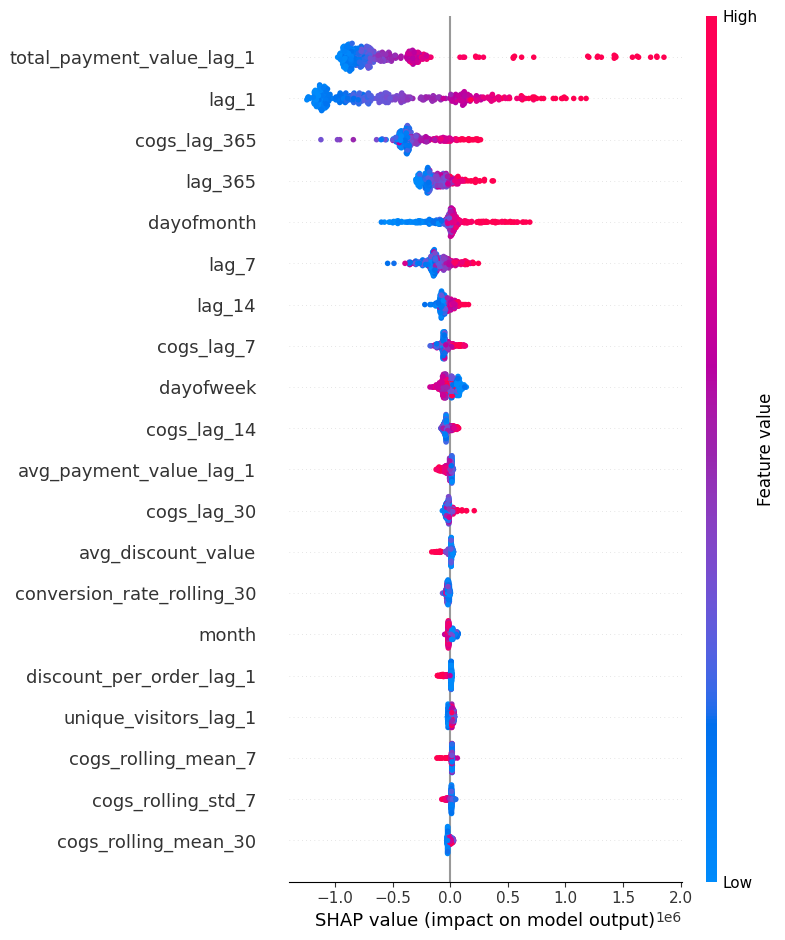

In [33]:
# SHAP for Revenue model
model = models["Revenue"]

if HAS_SHAP:
    sample_n = min(2000, len(X_valid))
    X_sample = X_valid.sample(sample_n, random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "shap_summary_revenue.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("SHAP not installed. Run: pip install shap")
